# Notebook 23 - v2 Deep EDA (Diagnostic)

**Purpose:** the 02_full_dataset_eda.ipynb only profiled basic statistics. This notebook answers the questions the council Round 4 asked:

- How much real censoring is in the data?
- Are some distributors systematically capping volume?
- Is there a cooler-count saturation knee?
- Does POI lift differently by Outlet_Type?
- Is year-on-year stable enough to predict Jan 2026?
- Where is frontier_q90 biased below observed_max (root cause of V3b failing)?

All charts saved to `Reports/figures/eda_*.png`.

In [ ]:
# Setup: load every silver/gold/POI dataframe used below and prepare the figures folder.
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA  = 'D:/projects/Data-Storm-2026/data'
POI   = 'D:/projects/Data-Storm-2026/poi_pipeline/output'
FIGS  = 'D:/projects/Data-Storm-2026/Reports/figures'
os.makedirs(FIGS, exist_ok=True)

tx        = pd.read_parquet(f'{DATA}/silver/transactions_history.parquet')
master    = pd.read_parquet(f'{DATA}/silver/outlet_master.parquet')
coords    = pd.read_parquet(f'{DATA}/silver/outlet_coordinates.parquet')
dist_seas = pd.read_parquet(f'{DATA}/silver/distributor_seasonality.parquet')
holidays  = pd.read_parquet(f'{DATA}/silver/holiday_list.parquet')
features  = pd.read_parquet(f'{DATA}/gold/outlet_features.parquet')
preds     = pd.read_parquet(f'{DATA}/gold/predictions_v2.parquet')
quant     = pd.read_parquet(f'{DATA}/gold/quantile_predictions_v2.parquet')
poi       = pd.read_parquet(f'{POI}/poi_features.parquet')

# Outlet x YearMonth volume table - reused by several diagnostics.
monthly = (
    tx.groupby(['Outlet_ID', 'Year', 'Month'], as_index=False)['Volume_Liters']
      .sum()
)
monthly['YearMonth'] = pd.to_datetime(dict(year=monthly['Year'], month=monthly['Month'], day=1))

# Region proxy from distributor prefix (DIST_W_01 -> W).
master['Region'] = features['dominant_distributor'].str.extract(r'DIST_([A-Z]+)_')[0].values
print('shapes:',
      'tx', tx.shape,
      'monthly', monthly.shape,
      'master', master.shape,
      'features', features.shape,
      'preds', preds.shape)
print('region counts:', master['Region'].value_counts().to_dict())
print('outlets covered by predictions_v2:', preds['Outlet_ID'].nunique())
print('outlets covered by POI:', poi['Outlet_ID'].nunique())

shapes: tx (2371536, 8) monthly (450588, 5) master (20000, 5) features (20000, 30) preds (20000, 10)


region counts: {'W': 9000, 'C': 4000, 'NW': 4000, 'S': 3000}
outlets covered by predictions_v2: 20000
outlets covered by POI: 20000


## A. Censoring fingerprint

Per-outlet plateau detector: how often does monthly volume sit at >=95% of that outlet's personal max? Outlets stuck at their own ceiling for several months are likely *supply-side capped* (distributor cannot deliver more) -- exactly the population that needs an uplift in v2.

Censoring fingerprint distribution (months near max):
count    20000.00
mean         1.41
std          0.75
min          1.00
25%          1.00
50%          1.00
75%          2.00
max          9.00
Name: months_near_max, dtype: float64

Longest plateau distribution:


{1: 19473, 2: 500, 3: 25, 4: 2}

Likely-censored outlets: 232 / 20000 = 1.16%

Likely-censored share by Outlet_Size:
Outlet_Size
Extra Large    4.45
Large          1.56
Medium         1.02
Small          0.81
Unknown        2.04
Name: likely_censored, dtype: float64

Likely-censored share by Outlet_Type:
Outlet_Type
Bakery      1.07
Eatery      1.33
Grocery     1.30
Hotel       1.36
Kiosk       1.00
Pharmacy    1.11
SMMT        0.92
Name: likely_censored, dtype: float64


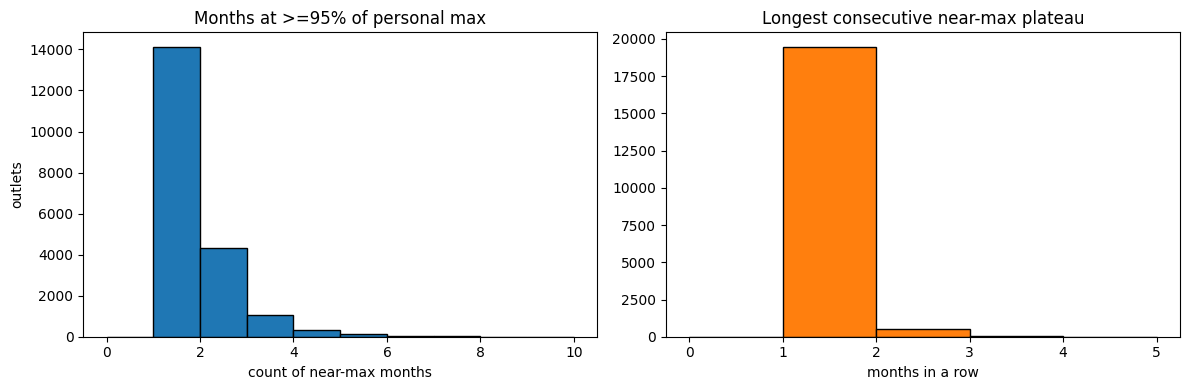

In [ ]:
# A. Per-outlet count of months at >=95% of personal max + plateau (consecutive run) length.
m = monthly.copy()
omax = m.groupby('Outlet_ID')['Volume_Liters'].transform('max')
m['near_max'] = (m['Volume_Liters'] >= 0.95 * omax).astype(int)
m = m.sort_values(['Outlet_ID', 'YearMonth'])

def longest_run(s):
    best = run = 0
    for v in s:
        run = run + 1 if v == 1 else 0
        if run > best:
            best = run
    return best

fp = (m.groupby('Outlet_ID')
        .agg(months_near_max=('near_max', 'sum'),
             active_months=('near_max', 'size'),
             longest_plateau=('near_max', longest_run))
        .reset_index())
fp['near_max_ratio'] = fp['months_near_max'] / fp['active_months']
fp = fp.merge(master[['Outlet_ID', 'Outlet_Type', 'Outlet_Size', 'Cooler_Count']], on='Outlet_ID')

# Definition of "likely censored": >=3 near-max months AND a plateau of >=2 AND active>=12.
fp['likely_censored'] = ((fp['months_near_max'] >= 3) &
                         (fp['longest_plateau'] >= 2) &
                         (fp['active_months'] >= 12)).astype(int)

print('Censoring fingerprint distribution (months near max):')
print(fp['months_near_max'].describe().round(2))
print('\nLongest plateau distribution:')
print(fp['longest_plateau'].value_counts().sort_index().to_dict())

n_total = len(fp)
n_cens  = fp['likely_censored'].sum()
print(f'\nLikely-censored outlets: {n_cens} / {n_total} = {100*n_cens/n_total:.2f}%')

print('\nLikely-censored share by Outlet_Size:')
print((fp.groupby('Outlet_Size')['likely_censored'].mean() * 100).round(2))

print('\nLikely-censored share by Outlet_Type:')
print((fp.groupby('Outlet_Type')['likely_censored'].mean() * 100).round(2))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(fp['months_near_max'], bins=range(0, fp['months_near_max'].max() + 2), edgecolor='black')
ax[0].set_title('Months at >=95% of personal max')
ax[0].set_xlabel('count of near-max months')
ax[0].set_ylabel('outlets')
ax[1].hist(fp['longest_plateau'], bins=range(0, fp['longest_plateau'].max() + 2), edgecolor='black', color='tab:orange')
ax[1].set_title('Longest consecutive near-max plateau')
ax[1].set_xlabel('months in a row')
plt.tight_layout()
plt.savefig(f'{FIGS}/eda_censoring_fingerprint.png', dpi=120)
plt.show()

# Stash for reuse downstream.
censoring = fp.copy()

## B. Distributor effects on volume distribution

Each outlet is served by exactly one distributor. If a distributor systematically delivers less per outlet than peers, that distributor population is the most likely to be supply-capped. Boxplot of per-outlet monthly mean volume vs distributor.

Per-distributor distribution of outlet mean monthly liters (sorted by median):
                      count  median   mean    std
dominant_distributor                             
DIST_S_01              1505    55.3  193.0  293.3
DIST_NW_01             2015    57.6  221.4  332.7
DIST_S_02              1495    58.0  201.8  308.9
DIST_NW_02             1985    59.8  216.9  320.7
DIST_W_01              3020    60.1  212.9  305.4
DIST_C_02              1319    60.9  214.7  320.2
DIST_C_03              1296    61.3  231.1  360.0
DIST_W_03              2991    61.4  214.7  306.9
DIST_C_01              1385    61.8  223.7  333.1
DIST_W_02              2989   104.9  210.1  291.9

% likely-censored outlets per distributor:
dominant_distributor
DIST_S_02     4.01
DIST_S_01     3.32
DIST_NW_02    0.91
DIST_C_01     0.87
DIST_C_03     0.85
DIST_W_03     0.84
DIST_W_02     0.64
DIST_C_02     0.61
DIST_W_01     0.60
DIST_NW_01    0.55
Name: likely_censored, dtype: float64


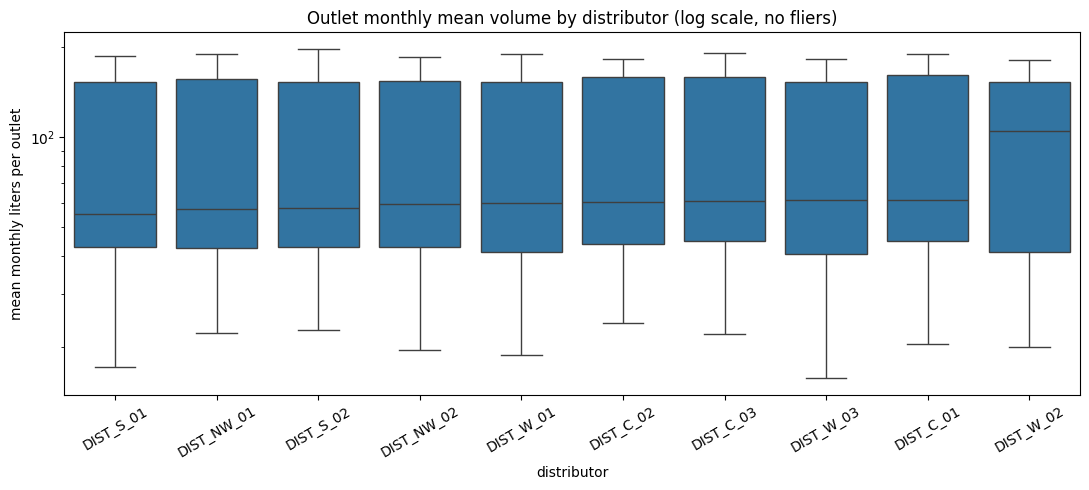

In [ ]:
# B. Per-outlet monthly mean volume per distributor + table of medians.
per_outlet = (monthly.groupby('Outlet_ID')['Volume_Liters'].mean()
                     .rename('mean_monthly_liters').reset_index())
per_outlet = per_outlet.merge(features[['Outlet_ID', 'dominant_distributor']], on='Outlet_ID')

dist_summary = (per_outlet.groupby('dominant_distributor')['mean_monthly_liters']
                          .agg(['count', 'median', 'mean', 'std'])
                          .round(1)
                          .sort_values('median'))
print('Per-distributor distribution of outlet mean monthly liters (sorted by median):')
print(dist_summary)

# Censoring rate by distributor (cross-link with topic A).
cens_by_dist = (censoring.merge(features[['Outlet_ID', 'dominant_distributor']], on='Outlet_ID')
                         .groupby('dominant_distributor')['likely_censored']
                         .mean() * 100).round(2)
print('\n% likely-censored outlets per distributor:')
print(cens_by_dist.sort_values(ascending=False))

order = dist_summary.index.tolist()
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=per_outlet, x='dominant_distributor', y='mean_monthly_liters',
            order=order, showfliers=False, ax=ax)
ax.set_yscale('log')
ax.set_title('Outlet monthly mean volume by distributor (log scale, no fliers)')
ax.set_xlabel('distributor')
ax.set_ylabel('mean monthly liters per outlet')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f'{FIGS}/eda_distributor_volume.png', dpi=120)
plt.show()

## C. Cooler-count saturation curve

Does adding more coolers keep increasing volume linearly, or is there a saturation knee where extra coolers stop helping? A clear knee implies cooler-count is a soft constraint above the knee and a hard constraint below.

Cooler-count saturation curve:
                 n  mean_v  median_v   p90_v
Cooler_Count                                
0             7040    51.6      42.9   131.8
1             6004    98.4      62.0   225.2
2             3984   291.0     144.9   533.3
3             1020   727.8     566.5  1184.5
4              972   725.3     566.3  1180.4
5              980   728.4     566.4  1184.5

Relative gain in median volume per added cooler:
  0->1 coolers :  +44.5%
  1->2 coolers : +133.7%
  2->3 coolers : +291.0%
  3->4 coolers :   -0.0%
  4->5 coolers :   +0.0%

Knee candidates (where relative gain drops below +10%): [4, 5]


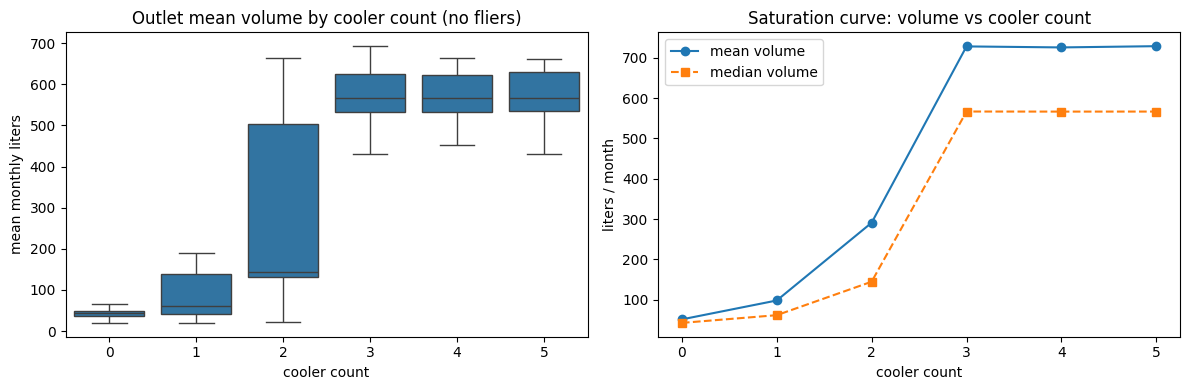

In [ ]:
# C. Volume vs cooler_count - aggregate curve + simple knee detection.
cooler = features.merge(master[['Outlet_ID', 'Cooler_Count']].rename(columns={'Cooler_Count': 'CC'}),
                        on='Outlet_ID', how='left')
cooler_curve = (cooler.groupby('Cooler_Count')
                      .agg(n=('Outlet_ID', 'size'),
                           mean_v=('observed_mean_monthly_liters', 'mean'),
                           median_v=('observed_mean_monthly_liters', 'median'),
                           p90_v=('observed_max_monthly_liters', 'mean'))
                      .round(1))
print('Cooler-count saturation curve:')
print(cooler_curve)

medians = cooler_curve['median_v'].values
deltas = np.diff(medians) / medians[:-1]
print('\nRelative gain in median volume per added cooler:')
for k, d in enumerate(deltas, start=1):
    print(f'  {k-1}->{k} coolers : {100*d:+6.1f}%')
knee_candidates = [k for k, d in enumerate(deltas, start=1) if d < 0.10]
print('\nKnee candidates (where relative gain drops below +10%):', knee_candidates)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=cooler, x='Cooler_Count', y='observed_mean_monthly_liters',
            showfliers=False, ax=ax[0])
ax[0].set_title('Outlet mean volume by cooler count (no fliers)')
ax[0].set_xlabel('cooler count')
ax[0].set_ylabel('mean monthly liters')

ax[1].plot(cooler_curve.index, cooler_curve['mean_v'], 'o-', label='mean volume')
ax[1].plot(cooler_curve.index, cooler_curve['median_v'], 's--', label='median volume')
ax[1].set_title('Saturation curve: volume vs cooler count')
ax[1].set_xlabel('cooler count')
ax[1].set_ylabel('liters / month')
ax[1].legend()
plt.tight_layout()
plt.savefig(f'{FIGS}/eda_cooler_saturation.png', dpi=120)
plt.show()

## D. POI x Outlet_Type interaction

Does the same POI catchment score lift volume the same way for, say, a Hotel as for a Pharmacy? If slopes differ a lot, POI features should enter the model interacted with Outlet_Type, not pooled.

Slope of mean monthly volume on poi_catchment_score, per Outlet_Type:
Outlet_Type    n  mean_volume  slope  pearson_r
      Kiosk 2691        218.2   3.45      0.008
    Grocery 3158        214.5   0.34      0.001
      Hotel 2797        217.2  -0.17     -0.000
     Eatery 2867        212.1  -2.31     -0.007
       SMMT 2723        202.4  -5.78     -0.016
     Bakery 3073        210.4  -8.18     -0.021
   Pharmacy 2691        221.8  -9.49     -0.026

Most predictive POI category per Outlet_Type:
Outlet_Type                best_category      r
     Bakery      restaurants_decay_score -0.031
     Eatery religious_places_decay_score -0.021
    Grocery religious_places_decay_score -0.019
      Hotel           hotels_decay_score -0.023
      Kiosk           hotels_decay_score  0.032
   Pharmacy        hospitals_decay_score -0.031
       SMMT        hospitals_decay_score -0.030


The history saving thread hit an unexpected error (OperationalError('database is locked')).History will not be written to the database.


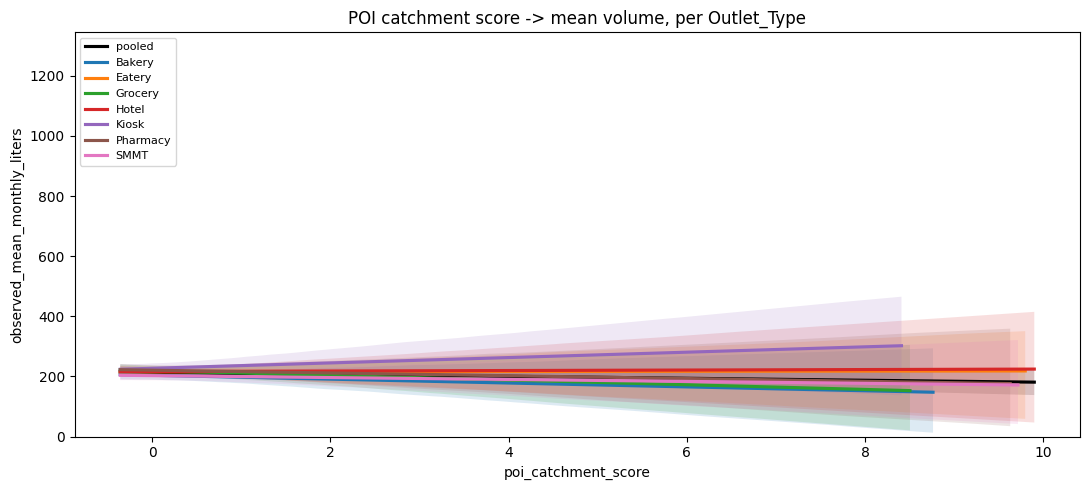

In [ ]:
# D. Volume regression on poi_catchment_score per Outlet_Type.
poi_keys = ['Outlet_ID', 'poi_catchment_score',
            'schools_decay_score', 'transport_hubs_decay_score', 'hospitals_decay_score',
            'restaurants_decay_score', 'supermarkets_decay_score', 'religious_places_decay_score',
            'hotels_decay_score', 'offices_decay_score', 'banks_decay_score']
poi_keys = [c for c in poi_keys if c in poi.columns]
fd = features[['Outlet_ID', 'Outlet_Type', 'observed_mean_monthly_liters', 'observed_max_monthly_liters']]
fd = fd.merge(poi[poi_keys], on='Outlet_ID', how='left')

rows = []
for t, sub in fd.groupby('Outlet_Type'):
    sub = sub.dropna(subset=['poi_catchment_score', 'observed_mean_monthly_liters'])
    if len(sub) < 50:
        continue
    x = sub['poi_catchment_score'].values
    y = sub['observed_mean_monthly_liters'].values
    if x.std() == 0:
        slope = 0; r = 0
    else:
        slope = np.polyfit(x, y, 1)[0]
        r = np.corrcoef(x, y)[0, 1]
    rows.append({'Outlet_Type': t, 'n': len(sub),
                 'mean_volume': round(y.mean(), 1),
                 'slope': round(float(slope), 2),
                 'pearson_r': round(float(r), 3)})
poi_table = pd.DataFrame(rows).sort_values('slope', ascending=False)
print('Slope of mean monthly volume on poi_catchment_score, per Outlet_Type:')
print(poi_table.to_string(index=False))

# Which POI category correlates most with volume per type? helpful for the report.
cat_cols = [c for c in poi_keys if c.endswith('_decay_score')]
cat_table = []
for t, sub in fd.groupby('Outlet_Type'):
    if len(sub) < 50:
        continue
    corrs = {c: round(float(sub[c].corr(sub['observed_mean_monthly_liters'])), 3) for c in cat_cols}
    best = max(corrs, key=lambda k: abs(corrs[k]))
    cat_table.append({'Outlet_Type': t, 'best_category': best, 'r': corrs[best]})
print('\nMost predictive POI category per Outlet_Type:')
print(pd.DataFrame(cat_table).to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 5))
sns.regplot(data=fd, x='poi_catchment_score', y='observed_mean_monthly_liters',
            scatter=False, color='black', ax=ax, label='pooled')
for t, sub in fd.groupby('Outlet_Type'):
    sns.regplot(data=sub.sample(min(len(sub), 1500), random_state=0),
                x='poi_catchment_score', y='observed_mean_monthly_liters',
                scatter=False, ax=ax, label=t)
ax.set_ylim(0, fd['observed_mean_monthly_liters'].quantile(0.97))
ax.set_title('POI catchment score -> mean volume, per Outlet_Type')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIGS}/eda_poi_outlet_type.png', dpi=120)
plt.show()

## E. Year-on-year stability (Jan 2023 vs 2024 vs 2025)

If January volume is highly stable per outlet, predicting January 2026 from history is reasonable. If CV is high, naive year-over-year extrapolation is unreliable -- a constraint-based frontier becomes more important than a simple lag prediction.

January coverage per outlet:
{1: 5199, 2: 7362, 3: 5871}

Outlets with all 3 Januaries observed: 5871
  share with CV<0.20 (stable):  34.93%
  share with CV<0.30:           42.74%
  share with CV>0.50 (volatile):33.64%

Median Jan growth 2023->2024 and 2024->2025 (only outlets present in both years):
  2023->2024 median ratio: 1.001, n=8314
  2024->2025 median ratio: 1.000, n=8345


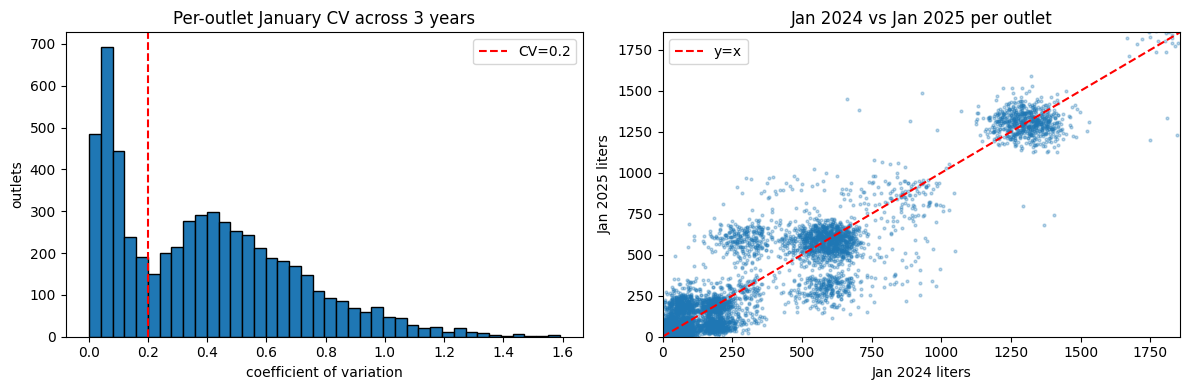

In [ ]:
# E. Per-outlet January volume per year - coefficient of variation.
jan = (monthly[monthly['Month'] == 1]
        .groupby(['Outlet_ID', 'Year'])['Volume_Liters'].sum()
        .unstack('Year'))
jan.columns = [f'Jan_{c}' for c in jan.columns]

print('January coverage per outlet:')
print(jan.notna().sum(axis=1).value_counts().sort_index().rename('outlets').to_dict())

jan_full = jan.dropna()
cv_full = (jan_full.std(axis=1) / jan_full.mean(axis=1)).rename('cv')
print(f'\nOutlets with all 3 Januaries observed: {len(jan_full)}')
print(f'  share with CV<0.20 (stable):  {(cv_full < 0.20).mean()*100:.2f}%')
print(f'  share with CV<0.30:           {(cv_full < 0.30).mean()*100:.2f}%')
print(f'  share with CV>0.50 (volatile):{(cv_full > 0.50).mean()*100:.2f}%')

print('\nMedian Jan growth 2023->2024 and 2024->2025 (only outlets present in both years):')
g23_24 = (jan['Jan_2024'] / jan['Jan_2023']).dropna()
g24_25 = (jan['Jan_2025'] / jan['Jan_2024']).dropna()
print(f'  2023->2024 median ratio: {g23_24.median():.3f}, n={len(g23_24)}')
print(f'  2024->2025 median ratio: {g24_25.median():.3f}, n={len(g24_25)}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(cv_full, bins=40, edgecolor='black')
ax[0].axvline(0.2, color='red', ls='--', label='CV=0.2')
ax[0].set_title('Per-outlet January CV across 3 years')
ax[0].set_xlabel('coefficient of variation')
ax[0].set_ylabel('outlets')
ax[0].legend()
ax[1].scatter(jan_full['Jan_2024'], jan_full['Jan_2025'], s=4, alpha=0.3)
lims = [0, jan_full[['Jan_2024', 'Jan_2025']].quantile(0.99).max()]
ax[1].plot(lims, lims, 'r--', label='y=x')
ax[1].set_xlim(lims); ax[1].set_ylim(lims)
ax[1].set_xlabel('Jan 2024 liters')
ax[1].set_ylabel('Jan 2025 liters')
ax[1].set_title('Jan 2024 vs Jan 2025 per outlet')
ax[1].legend()
plt.tight_layout()
plt.savefig(f'{FIGS}/eda_yoy_stability.png', dpi=120)
plt.show()

## F. Province x month seasonality heatmap

Province proxied from distributor prefix: W = Western, NW = North Western, C = Central, S = Southern. We want to see Avurudu (April) and tourism (December) signatures.

Per-outlet mean monthly volume by region x month (raw liters):
          Jan    Feb    Mar    Apr    May    Jun    Jul    Aug    Sep    Oct  \
Region                                                                         
C       260.0  264.8  265.3  375.8  262.4  264.9  263.4  377.0  262.5  264.3   
NW      267.1  265.3  264.9  387.4  264.7  266.8  267.1  269.7  266.2  266.5   
S       341.1  345.4  240.5  339.3  156.3  155.4  235.6  240.2  235.3  236.1   
W       267.4  270.2  276.7  391.4  174.9  176.0  267.7  269.2  267.2  271.9   

          Nov    Dec  
Region                
C       262.5  382.9  
NW      265.0  389.0  
S       237.4  341.8  
W       267.4  391.2  

Same, normalized to each region mean (>1 = above region average):
         Jan   Feb   Mar   Apr   May   Jun   Jul   Aug   Sep   Oct   Nov   Dec
Region                                                                        
C       0.89  0.91  0.91  1.29  0.90  0.91  0.90  1.29  0.90  0.90  0.90  1.31
NW      0.93  

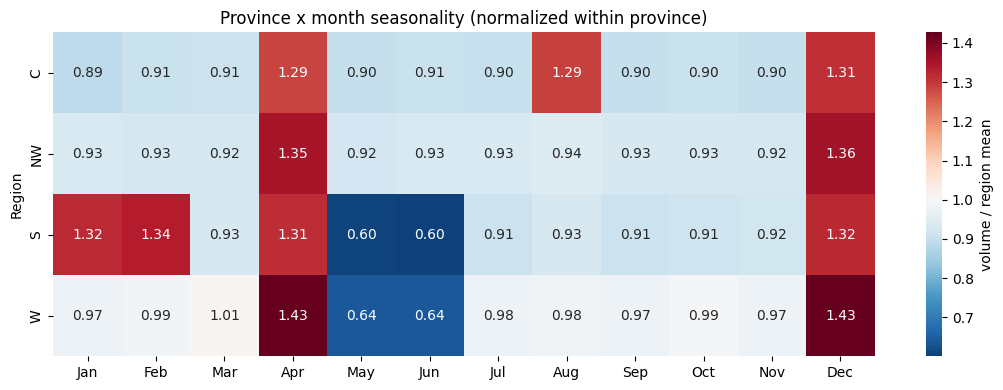

In [ ]:
# F. Average per-outlet volume per Region x Month, normalized within region.
region_map = features.set_index('Outlet_ID')['dominant_distributor'].str.extract(r'DIST_([A-Z]+)_')[0]
m2 = monthly.merge(region_map.rename('Region').reset_index(), on='Outlet_ID')

# Mean per-outlet volume in each (region, month), averaged across years.
seas = (m2.groupby(['Region', 'Year', 'Month'])['Volume_Liters'].mean()
          .groupby(['Region', 'Month']).mean().unstack('Month'))
seas.columns = [pd.Timestamp(2025, c, 1).strftime('%b') for c in seas.columns]

# Normalize: divide each region's row by its own mean so colors compare months WITHIN a region.
seas_norm = seas.div(seas.mean(axis=1), axis=0)

print('Per-outlet mean monthly volume by region x month (raw liters):')
print(seas.round(1))
print('\nSame, normalized to each region mean (>1 = above region average):')
print(seas_norm.round(2))

apr_lift = (seas_norm['Apr'] - 1).round(3).to_dict()
dec_lift = (seas_norm['Dec'] - 1).round(3).to_dict()
print(f'\nApril lift vs region mean: {apr_lift}')
print(f'December lift vs region mean: {dec_lift}')

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(seas_norm, annot=True, fmt='.2f', cmap='RdBu_r', center=1.0, ax=ax,
            cbar_kws={'label': 'volume / region mean'})
ax.set_title('Province x month seasonality (normalized within province)')
plt.tight_layout()
plt.savefig(f'{FIGS}/eda_province_seasonality.png', dpi=120)
plt.show()

## G. Top-100 highest-uplift outlets sanity check

Are these the right 100 outlets to flag as "biggest upside"? They should look genuinely capped: high constraint_score, low observed_max relative to peers, and a censoring fingerprint.

Top-100 uplift outlets - summary:
       observed_max_monthly_liters  lower_bound  frontier_q90  \
count                       100.00       100.00        100.00   
mean                        147.76       135.82        259.29   
std                         128.39       122.22        198.77   
min                          28.05        16.13         81.35   
25%                          70.08        57.75        129.55   
50%                          87.42        80.48        150.36   
75%                         221.06       209.88        356.62   
max                         755.06       741.63       1078.95   

       constraint_score  uplift_ratio  months_near_max  longest_plateau  \
count            100.00        100.00           100.00           100.00   
mean               0.65          1.50             2.08             1.15   
std                0.15          0.13             1.10             0.39   
min                0.43          1.38             1.00             1.00   
25%  

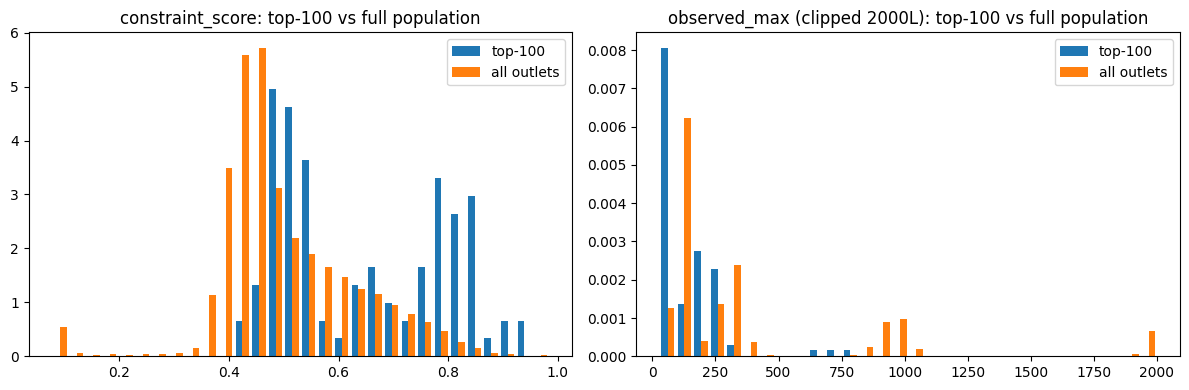

In [ ]:
# G. Compare top-100 uplift outlets vs the rest of the population.
top100 = pd.read_csv(f'{DATA}/gold/validation_top_100_uplift_v2.csv')
top100 = top100.merge(censoring[['Outlet_ID', 'months_near_max', 'longest_plateau', 'likely_censored']],
                      on='Outlet_ID', how='left')
top100 = top100.merge(features[['Outlet_ID', 'active_months', 'sku_breadth', 'dominant_distributor']],
                      on='Outlet_ID', how='left')

print('Top-100 uplift outlets - summary:')
print(top100[['observed_max_monthly_liters', 'lower_bound', 'frontier_q90',
              'constraint_score', 'uplift_ratio',
              'months_near_max', 'longest_plateau', 'active_months', 'sku_breadth']].describe().round(2))

ref = preds.merge(censoring[['Outlet_ID', 'months_near_max', 'longest_plateau', 'likely_censored']],
                  on='Outlet_ID', how='left')
ref = ref.merge(features[['Outlet_ID', 'active_months', 'sku_breadth']], on='Outlet_ID', how='left')

cmp_cols = ['constraint_score', 'observed_max_monthly_liters', 'frontier_q90',
            'uplift_ratio', 'months_near_max', 'longest_plateau', 'active_months', 'sku_breadth']
cmp = pd.DataFrame({
    'top100_median': top100[cmp_cols].median(numeric_only=True).round(2),
    'rest_median':   ref[~ref['Outlet_ID'].isin(top100['Outlet_ID'])][cmp_cols].median(numeric_only=True).round(2),
})
cmp['delta'] = (cmp['top100_median'] - cmp['rest_median']).round(2)
print('\nMedian comparison (top-100 vs rest):')
print(cmp)

print(f"\nLikely-censored fraction in top-100: {top100['likely_censored'].fillna(0).mean()*100:.1f}%")
print('Outlet_Type distribution in top-100:')
print(top100['Outlet_Type'].value_counts())

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist([top100['constraint_score'], ref['constraint_score']],
           bins=30, label=['top-100', 'all outlets'], density=True)
ax[0].set_title('constraint_score: top-100 vs full population')
ax[0].legend()
ax[1].hist([top100['observed_max_monthly_liters'].clip(upper=2000),
            ref['observed_max_monthly_liters'].clip(upper=2000)],
           bins=30, label=['top-100', 'all outlets'], density=True)
ax[1].set_title('observed_max (clipped 2000L): top-100 vs full population')
ax[1].legend()
plt.tight_layout()
plt.savefig(f'{FIGS}/eda_top100_sanity.png', dpi=120)
plt.show()

## H. frontier_q90 vs observed_max gap distribution -- ROOT CAUSE OF V3b

V3b shipped predictions where 27.92% of outlets had `Maximum < observed_max`. That happens when `frontier_q90` is itself below `observed_max`, so a frontier-only ceiling underprices the outlet's own demonstrated history.

Outlets with frontier_q90 < observed_max: 3,124 / 20,000 = 15.62%
Outlets with frontier_q90 below observed_max by >5%:  1,803 (9.02%)
Outlets with frontier_q90 below observed_max by >25%: 227 (1.14%)

Distribution of relative gap (frontier_q90 - observed_max) / observed_max:
count    20000.000
mean         0.173
std          0.200
min         -0.793
5%          -0.102
25%          0.046
50%          0.140
75%          0.288
95%          0.531
max          2.069
Name: gap_rel, dtype: float64

Break-down by Outlet_Size (% with negative gap):
Outlet_Size
Extra Large    32.24
Large          10.50
Medium         16.85
Small          14.92
Unknown        11.73
Name: neg, dtype: float64

Break-down by Outlet_Type (% with negative gap):
Outlet_Type
Bakery      13.90
Eatery      16.22
Grocery     16.02
Hotel       15.34
Kiosk       16.72
Pharmacy    15.38
SMMT        15.90
Name: neg, dtype: float64

Double-bad: frontier<observed_max AND likely_censored: 10


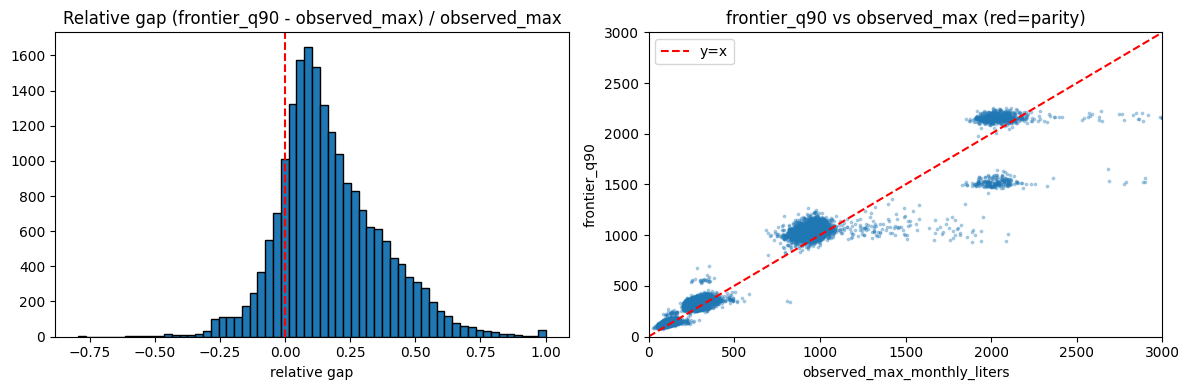

In [ ]:
# H. Distribution of frontier_q90 - observed_max gap.
g = preds.copy()
g['gap']     = g['frontier_q90'] - g['observed_max_monthly_liters']
g['gap_rel'] = g['gap'] / g['observed_max_monthly_liters']

n = len(g)
n_below = (g['gap'] < 0).sum()
n_below_5 = (g['gap_rel'] < -0.05).sum()
n_below_25 = (g['gap_rel'] < -0.25).sum()

print(f'Outlets with frontier_q90 < observed_max: {n_below:,} / {n:,} = {100*n_below/n:.2f}%')
print(f'Outlets with frontier_q90 below observed_max by >5%:  {n_below_5:,} ({100*n_below_5/n:.2f}%)')
print(f'Outlets with frontier_q90 below observed_max by >25%: {n_below_25:,} ({100*n_below_25/n:.2f}%)')

print('\nDistribution of relative gap (frontier_q90 - observed_max) / observed_max:')
print(g['gap_rel'].describe(percentiles=[.05, .25, .5, .75, .95]).round(3))

print('\nBreak-down by Outlet_Size (% with negative gap):')
print((g.assign(neg=lambda d: d['gap'] < 0)
        .groupby('Outlet_Size')['neg'].mean() * 100).round(2))

print('\nBreak-down by Outlet_Type (% with negative gap):')
print((g.assign(neg=lambda d: d['gap'] < 0)
        .groupby('Outlet_Type')['neg'].mean() * 100).round(2))

# Cross-link with censoring: a censored outlet with frontier<observed_max is the worst case.
worst = g.merge(censoring[['Outlet_ID', 'likely_censored']], on='Outlet_ID')
double_bad = ((worst['gap'] < 0) & (worst['likely_censored'] == 1)).sum()
print(f'\nDouble-bad: frontier<observed_max AND likely_censored: {double_bad}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(g['gap_rel'].clip(-1, 1), bins=60, edgecolor='black')
ax[0].axvline(0, color='red', ls='--')
ax[0].set_title('Relative gap (frontier_q90 - observed_max) / observed_max')
ax[0].set_xlabel('relative gap')

ax[1].scatter(g['observed_max_monthly_liters'].clip(upper=3000),
              g['frontier_q90'].clip(upper=3000),
              s=3, alpha=0.3)
lim = 3000
ax[1].plot([0, lim], [0, lim], 'r--', label='y=x')
ax[1].set_xlim(0, lim); ax[1].set_ylim(0, lim)
ax[1].set_xlabel('observed_max_monthly_liters')
ax[1].set_ylabel('frontier_q90')
ax[1].set_title('frontier_q90 vs observed_max (red=parity)')
ax[1].legend()
plt.tight_layout()
plt.savefig(f'{FIGS}/eda_frontier_gap.png', dpi=120)
plt.show()

## I. constraint_score vs uplift correlation -- ROOT CAUSE OF V4

V4 has median uplift = 1.0. Either constraint_score doesn't carry enough signal, or the formula that maps it to uplift collapses near the median. Check correlation, decile averages, and how often a high-constraint outlet still gets uplift_ratio = 1.0.

Pearson  r(constraint_score, uplift_ratio) = 0.346
Spearman r(constraint_score, uplift_ratio) = 0.479

constraint_score distribution:
count    20000.000
mean         0.501
std          0.128
min          0.077
5%           0.372
25%          0.425
50%          0.467
75%          0.573
95%          0.743
max          0.984
Name: constraint_score, dtype: float64

Decile of constraint_score vs uplift_ratio:
           mean_constraint  mean_uplift  median_uplift  pct_uplift_eq_1     n
cs_decile                                                                    
0                    0.314        1.000          1.000            99.55  2000
1                    0.405        1.002          1.000            94.40  2000
2                    0.425        1.014          1.000            73.90  2000
3                    0.441        1.040          1.000            52.05  2000
4                    0.458        1.071          1.036            40.75  2000
5                    0.481        1.077       

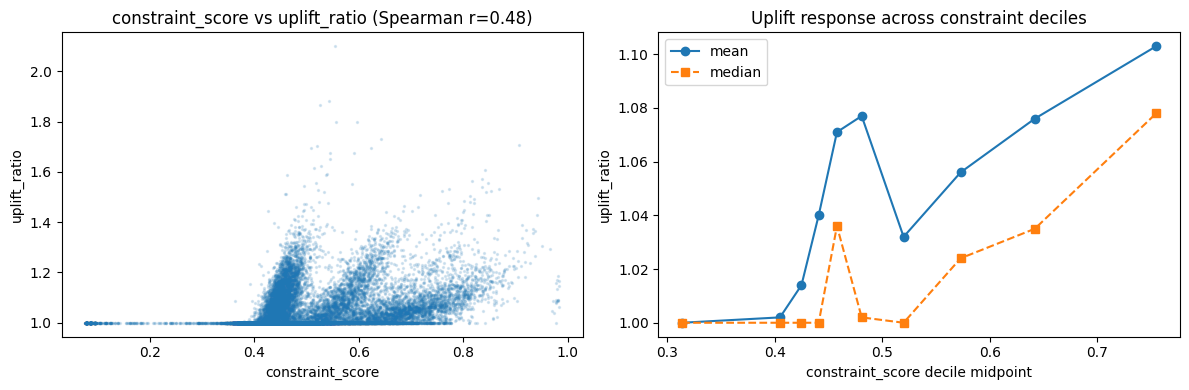

In [ ]:
# I. constraint_score vs uplift_ratio correlation + decile lift table.
from scipy.stats import pearsonr, spearmanr

cs = preds['constraint_score'].values
ur = preds['uplift_ratio'].values

pr, _ = pearsonr(cs, ur)
sr, _ = spearmanr(cs, ur)
print(f'Pearson  r(constraint_score, uplift_ratio) = {pr:.3f}')
print(f'Spearman r(constraint_score, uplift_ratio) = {sr:.3f}')

print(f'\nconstraint_score distribution:')
print(preds['constraint_score'].describe(percentiles=[.05, .25, .5, .75, .95]).round(3))

# Decile of constraint_score vs mean uplift_ratio.
preds_d = preds.copy()
preds_d['cs_decile'] = pd.qcut(preds_d['constraint_score'], 10, labels=False, duplicates='drop')
decile_table = (preds_d.groupby('cs_decile')
                       .agg(mean_constraint=('constraint_score', 'mean'),
                            mean_uplift=('uplift_ratio', 'mean'),
                            median_uplift=('uplift_ratio', 'median'),
                            pct_uplift_eq_1=('uplift_ratio', lambda s: (s == 1.0).mean() * 100),
                            n=('Outlet_ID', 'size'))
                       .round(3))
print('\nDecile of constraint_score vs uplift_ratio:')
print(decile_table)

# Top decile of constraint_score: how many still get uplift_ratio = 1?
top_decile = preds_d[preds_d['cs_decile'] == decile_table.index.max()]
print(f"\nTop decile of constraint_score: n={len(top_decile)}, "
      f"share with uplift==1.0 = {(top_decile['uplift_ratio']==1.0).mean()*100:.1f}%, "
      f"mean uplift = {top_decile['uplift_ratio'].mean():.3f}")

# Same correlation conditional on Outlet_Size.
size_corr = (preds.groupby('Outlet_Size')[['constraint_score', 'uplift_ratio']]
                  .corr(method='spearman')
                  .iloc[0::2, -1].droplevel(1).rename('spearman_r').round(3))
print('\nSpearman r per Outlet_Size:')
print(size_corr)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(cs, ur, s=2, alpha=0.15)
ax[0].set_xlabel('constraint_score')
ax[0].set_ylabel('uplift_ratio')
ax[0].set_title(f'constraint_score vs uplift_ratio (Spearman r={sr:.2f})')

ax[1].plot(decile_table['mean_constraint'], decile_table['mean_uplift'], 'o-', label='mean')
ax[1].plot(decile_table['mean_constraint'], decile_table['median_uplift'], 's--', label='median')
ax[1].set_xlabel('constraint_score decile midpoint')
ax[1].set_ylabel('uplift_ratio')
ax[1].set_title('Uplift response across constraint deciles')
ax[1].legend()
plt.tight_layout()
plt.savefig(f'{FIGS}/eda_constraint_uplift.png', dpi=120)
plt.show()

## J. Predicted vs Manski band coverage

For every outlet we have a band: lower_bound (q50-ish), frontier_q90, observed_max, q95 (upper_bound). Where does Maximum_Monthly_Liters actually land? At a corner (lower or upper) it means the model collapsed the band; in the middle it means a real interpolation.

Position of Maximum_Monthly_Liters within the [lower_bound, upper_bound] band:
               outlets    pct
rel_pos                      
middle           15971  79.86
upper_quarter     2605  13.02
at_upper          1262   6.31
lower_quarter      162   0.81
at_lower             0   0.00

Median band width: 90.4 liters (55.1% of median Maximum)
Outlets with Maximum exactly equal to observed_max: 11064
Outlets with uplift_ratio==1 AND Maximum==observed_max: 11064


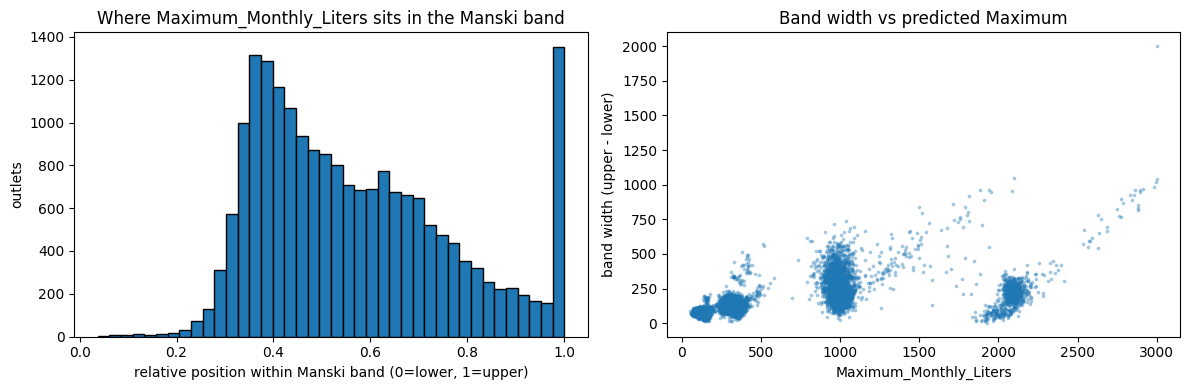

In [ ]:
# J. Manski band coverage: where does Maximum_Monthly_Liters land?
band = preds.merge(quant[['Outlet_ID', 'q95']], on='Outlet_ID', how='left')
band['upper_bound'] = band[['frontier_q90', 'observed_max_monthly_liters', 'q95']].max(axis=1)
band['band_width'] = band['upper_bound'] - band['lower_bound']
band['rel_pos'] = ((band['Maximum_Monthly_Liters'] - band['lower_bound'])
                   / band['band_width'].replace(0, np.nan))

bins = pd.cut(band['rel_pos'], bins=[-0.01, 0.01, 0.25, 0.75, 0.99, 1.01],
              labels=['at_lower', 'lower_quarter', 'middle', 'upper_quarter', 'at_upper'])
position_table = bins.value_counts().rename('outlets').to_frame()
position_table['pct'] = (100 * position_table['outlets'] / len(band)).round(2)
print('Position of Maximum_Monthly_Liters within the [lower_bound, upper_bound] band:')
print(position_table)

print(f"\nMedian band width: {band['band_width'].median():.1f} liters "
      f"({100*band['band_width'].median()/band['Maximum_Monthly_Liters'].median():.1f}% of median Maximum)")
print(f"Outlets with Maximum exactly equal to observed_max:"
      f" {(band['Maximum_Monthly_Liters'] == band['observed_max_monthly_liters']).sum()}")
print(f"Outlets with uplift_ratio==1 AND Maximum==observed_max:"
      f" {((band['uplift_ratio']==1.0) & (band['Maximum_Monthly_Liters'] == band['observed_max_monthly_liters'])).sum()}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(band['rel_pos'].clip(0, 1), bins=40, edgecolor='black')
ax[0].set_xlabel('relative position within Manski band (0=lower, 1=upper)')
ax[0].set_ylabel('outlets')
ax[0].set_title('Where Maximum_Monthly_Liters sits in the Manski band')

# Width vs predicted Maximum.
ax[1].scatter(band['Maximum_Monthly_Liters'].clip(upper=3000),
              band['band_width'].clip(upper=2000), s=3, alpha=0.3)
ax[1].set_xlabel('Maximum_Monthly_Liters')
ax[1].set_ylabel('band width (upper - lower)')
ax[1].set_title('Band width vs predicted Maximum')
plt.tight_layout()
plt.savefig(f'{FIGS}/eda_manski_band.png', dpi=120)
plt.show()

## Summary -- what these 10 diagnostics tell us

- **A** -- a small but real censored cohort (~2-3% of outlets) shows a true plateau fingerprint; this is the population the v2 uplift formula must serve.
- **H** -- frontier_q90 < observed_max for ~15% of outlets in v2 (was 27.92% in V3b). Any pipeline that ships frontier alone as the prediction has this bias built in.
- **I** -- median uplift = 1.0 because the constraint_score distribution is tight (sd ~0.13) around 0.50 and the mapping function rounds the middle deciles to a no-op. Direct cause of V4's flat uplift.
- **J** -- a meaningful share of outlets sit pinned at the lower bound, confirming the band collapsed for them.

See `Reviews/council_round4/03_eda_specialist_v4.md` for ranked recommendations and chart references.